# Using the same 2023 Kernel

In [1]:
# ============================================
# County-level PM2.5 forecaster:
#  - Train on 2023 county means (heteroskedastic noise)
#  - Plug-in forecast for 2024 using same kernel structure & 3 lags
#  - Evaluate vs imputed 2024 (RMSE, MAE, Skill vs persistence)
#  - Save predictions to pm25_2024_by_county_week_pred.csv
# ============================================
import warnings, time
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (Kernel, Matern, ExpSineSquared, RBF, WhiteKernel, ConstantKernel as C)
from scipy.optimize import fmin_l_bfgs_b

warnings.filterwarnings("ignore", category=UserWarning)

# ------------ Paths ------------
PATH_2023 = "pm25_2023_by_county_week_cov.csv"
PATH_2024 = "pm25_2024_by_county_week_cov.csv"
OUT_PRED  = "pm25_2024_by_county_week_pred.csv"

# ------------ Utilities ------------
class SliceKernel(Kernel):
    def __init__(self, base_kernel, active_dims):
        self.base_kernel = base_kernel
        self.active_dims = tuple(active_dims)
    def __call__(self, X, Y=None, eval_gradient=False):
        idx = np.asarray(self.active_dims)
        Xs = X[:, idx]
        Ys = None if Y is None else Y[:, idx]
        return self.base_kernel(Xs, Ys, eval_gradient=eval_gradient)
    def diag(self, X):
        idx = np.asarray(self.active_dims)
        return self.base_kernel.diag(X[:, idx])
    def is_stationary(self):
        return getattr(self.base_kernel, "is_stationary", lambda: False)()
    @property
    def hyperparameters(self): return self.base_kernel.hyperparameters
    @property
    def theta(self): return self.base_kernel.theta
    @theta.setter
    def theta(self, t): self.base_kernel.theta = t
    @property
    def bounds(self): return self.base_kernel.bounds
    def clone_with_theta(self, theta): return SliceKernel(self.base_kernel.clone_with_theta(theta), self.active_dims)
    def get_params(self, deep=True):
        params = {"base_kernel": self.base_kernel, "active_dims": self.active_dims}
        if deep and hasattr(self.base_kernel, "get_params"):
            for k, v in self.base_kernel.get_params(deep=True).items():
                params[f"base_kernel__{k}"] = v
        return params
    def set_params(self, **params):
        base_params = {k.split("__",1)[1]: v for k,v in params.items() if k.startswith("base_kernel__")}
        if base_params and hasattr(self.base_kernel, "set_params"):
            self.base_kernel.set_params(**base_params)
        if "base_kernel" in params: self.base_kernel = params["base_kernel"]
        if "active_dims" in params: self.active_dims = tuple(params["active_dims"])
        return self
    def __repr__(self):
        return f"SliceKernel(base_kernel={self.base_kernel!r}, active_dims={self.active_dims!r})"

def lbfgs_capped(obj_func, initial_theta, bounds, MAXITER=30):
    theta_opt, fmin, _ = fmin_l_bfgs_b(obj_func, initial_theta, bounds=bounds, maxiter=MAXITER)
    return theta_opt, fmin

def build_county_kernel(idx_time=(0,), idx_lags=(1,2,3)):
    # Same structure you used before (time short/long + periodic) + ARD on lags + White noise
    K_time_short = SliceKernel(C(0.7**2, (1e-3, 1e3)) * Matern(length_scale=2.0,  nu=0.5,  length_scale_bounds=(0.2, 20.0)), idx_time)
    K_time_long  = SliceKernel(C(0.5**2, (1e-3, 1e3)) * Matern(length_scale=12.0, nu=1.5, length_scale_bounds=(4.0, 104.0)), idx_time)
    K_per        = SliceKernel(C(0.5**2, (1e-3, 1e3)) * ExpSineSquared(length_scale=5.0, periodicity=52.0,
                                                                       length_scale_bounds=(1.0, 20.0),
                                                                       periodicity_bounds="fixed"), idx_time)
    K_lags       = SliceKernel(C(1.2**2, (1e-3, 1e3)) * RBF(length_scale=[1.0, 2.0, 5.0], length_scale_bounds=(0.05, 50.0)), idx_lags)
    k_noise      = WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-6, 1.0))
    return K_time_short + (0.3**2)*K_time_long + K_per + K_lags + k_noise

def make_gp(kernel, alpha_array, random_state=42, MAXITER=30, RESTARTS=1):
    # scikit-learn calls optimizer(obj_func, initial_theta, bounds=...)
    def _optimizer(obj_func, initial_theta, bounds):
        return lbfgs_capped(obj_func, initial_theta, bounds, MAXITER=MAXITER)

    return Pipeline([
        ("scale", StandardScaler()),
        ("gpr", GaussianProcessRegressor(
            kernel=kernel,
            alpha=np.asarray(alpha_array, float),  # heteroskedastic noise per sample
            optimizer=_optimizer,
            n_restarts_optimizer=RESTARTS,
            normalize_y=True,
            random_state=random_state,
            copy_X_train=False,
        ))
    ])


def add_lags(s, n_lags=3, col='PM2.5_county_mean'):
    s = s.sort_values("ds").copy()
    for k in range(1, n_lags+1):
        s[f"lag_{k}"] = s[col].shift(k)
    return s

def weekly_index(df):
    base = df["ds"].min()
    return ((df["ds"] - base).dt.days / 7.0).astype(float)

def rmse(y, yhat):
    y = np.asarray(y, float); yhat = np.asarray(yhat, float)
    m = np.isfinite(y) & np.isfinite(yhat)
    return float(np.sqrt(np.mean((y[m] - yhat[m])**2))) if m.any() else np.nan

def mae(y, yhat):
    y = np.asarray(y, float); yhat = np.asarray(yhat, float)
    m = np.isfinite(y) & np.isfinite(yhat)
    return float(np.mean(np.abs(y[m] - yhat[m]))) if m.any() else np.nan

# ------------ Load data ------------
d23 = pd.read_csv(PATH_2023, parse_dates=["ds"])
d24 = pd.read_csv(PATH_2024, parse_dates=["ds"])

# Limit evaluation to counties present in both years
common = sorted(set(d23.County.unique()) & set(d24.County.unique()))
d23 = d23[d23.County.isin(common)].copy()
d24 = d24[d24.County.isin(common)].copy()

# Build time indices (use 2023 base so 2024 sits “in the future” on same axis)
t0 = d23["ds"].min()
d23["t_week"] = ((d23["ds"] - t0).dt.days / 7.0).astype(float)
d24["t_week"] = ((d24["ds"] - t0).dt.days / 7.0).astype(float)

# ------------ Fit per-county GPs on 2023; forecast 2024 ------------
pred_rows = []
start = time.perf_counter()

for c in common:
    g23 = d23[d23.County == c].sort_values("ds").copy()
    g24 = d24[d24.County == c].sort_values("ds").copy()
    if g23.empty or g24.empty:
        continue

    # Add 3 lags on 2023 training
    g23 = add_lags(g23, 3, col="PM2.5_county_mean")
    tr = g23.dropna(subset=["PM2.5_county_mean", "lag_1","lag_2","lag_3"]).copy()
    if len(tr) < 8:
        # not enough data with lags
        continue

    X_tr = tr[["t_week","lag_1","lag_2","lag_3"]].to_numpy(float)
    y_tr = tr["PM2.5_county_mean"].to_numpy(float)
    a_tr = np.clip(tr["PM2.5_county_var"].to_numpy(float), 1e-8, None)  # heteroskedastic noise

    # Kernel + GP
    idx_time, idx_lags = (0,), (1,2,3)
    kernel = build_county_kernel(idx_time, idx_lags)
    gp = make_gp(kernel, alpha_array=a_tr, MAXITER=30, RESTARTS=1)

    # Fit
    gp.fit(X_tr, y_tr)

    # Roll forward 2024 using plug-in lags
    # Seed with the final three *observed* (imputed) weeks from 2023
    g23_tail = g23.sort_values("ds").tail(3)
    if len(g23_tail) < 3:
        continue
    last_vals = g23_tail["PM2.5_county_mean"].tolist()

    # Predict for each 2024 week in chronological order
    for _, row in g24.iterrows():
        t = float(row["t_week"])
        l1, l2, l3 = last_vals[-1], last_vals[-2], last_vals[-3]
        x = np.array([[t, l1, l2, l3]], dtype=float)
        yhat = float(gp.predict(x, return_std=False).ravel()[0])
        pred_rows.append({"County": c, "ds": row["ds"], "PM2.5_pred_2024": yhat})
        # plug-in update
        last_vals.append(yhat)

elapsed = time.perf_counter() - start
pred = pd.DataFrame(pred_rows).sort_values(["County","ds"]).reset_index(drop=True)
pred.to_csv(OUT_PRED, index=False)
print(f"Saved forecasts: {OUT_PRED}  |  counties: {pred['County'].nunique()}  |  secs: {elapsed:.1f}")

# ------------ Evaluation vs imputed 2024 ------------
eval_df = (pred.merge(d24[["County","ds","PM2.5_county_mean"]], on=["County","ds"], how="inner")
                .rename(columns={"PM2.5_county_mean":"PM2.5_truth_2024"}))

# Full-year metrics
rmse_full = rmse(eval_df["PM2.5_truth_2024"], eval_df["PM2.5_pred_2024"])
mae_full  = mae (eval_df["PM2.5_truth_2024"], eval_df["PM2.5_pred_2024"])

# Jan–Apr subset (months 1..4)
jan_apr = eval_df[eval_df["ds"].dt.month.isin([1,2,3,4])]
rmse_ja = rmse(jan_apr["PM2.5_truth_2024"], jan_apr["PM2.5_pred_2024"])
mae_ja  = mae (jan_apr["PM2.5_truth_2024"], jan_apr["PM2.5_pred_2024"])

# Naive persistence baseline (uses prior week's *truth*; good sanity baseline)
def persistence(y):
    y = np.asarray(y, float)
    z = np.empty_like(y); z[:] = np.nan
    z[1:] = y[:-1]
    return z

eval_df = eval_df.sort_values(["County","ds"]).reset_index(drop=True)
eval_df["naive"] = eval_df.groupby("County")["PM2.5_truth_2024"].transform(persistence)

# Compute skill vs persistence where naive is defined
mask = np.isfinite(eval_df["naive"])
rmse_persist = rmse(eval_df.loc[mask, "PM2.5_truth_2024"], eval_df.loc[mask, "naive"])
skill_full = 1.0 - (rmse_full / rmse_persist) if (rmse_full is not None and rmse_persist and np.isfinite(rmse_persist) and rmse_persist>0) else np.nan

# Jan–Apr skill
ja = eval_df[eval_df["ds"].dt.month.isin([1,2,3,4])]
mask_ja = np.isfinite(ja["naive"])
rmse_persist_ja = rmse(ja.loc[mask_ja, "PM2.5_truth_2024"], ja.loc[mask_ja, "naive"])
skill_ja = 1.0 - (rmse_ja / rmse_persist_ja) if (np.isfinite(rmse_persist_ja) and rmse_persist_ja>0) else np.nan

print("\n=== County-level PM2.5 forecast vs imputed 2024 ===")
print(f"Full 2024: RMSE={rmse_full:.3f} | MAE={mae_full:.3f} | Skill vs persistence={skill_full:.3f}")
print(f"Jan–Apr : RMSE={rmse_ja:.3f} | MAE={mae_ja:.3f} | Skill vs persistence={skill_ja:.3f}")


Saved forecasts: pm25_2024_by_county_week_pred.csv  |  counties: 50  |  secs: 22.6

=== County-level PM2.5 forecast vs imputed 2024 ===
Full 2024: RMSE=2.892 | MAE=2.109 | Skill vs persistence=-0.241
Jan–Apr : RMSE=2.257 | MAE=1.885 | Skill vs persistence=-0.167


In [2]:
# ============================================
# County-level PM2.5 forecaster (self-contained):
# - Loads 2023/2024 county-week CSVs
# - Forces Jan 6/13/20 2024 into the prediction grid
# - Trains per-county GP on 2023 (heteroskedastic)
# - Rolls forward through full 2024 weekly calendar
# - Evaluates only where d24 has truth
# - Writes pm25_2024_by_county_week_pred.csv
# ============================================
import warnings, time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (Kernel, Matern, ExpSineSquared, RBF, WhiteKernel, ConstantKernel as C)
from scipy.optimize import fmin_l_bfgs_b

warnings.filterwarnings("ignore", category=UserWarning)

# ------------ Paths (kept the same names) ------------
try:
    PATH_2023
except NameError:
    PATH_2023 = "pm25_2023_by_county_week_cov.csv"
try:
    PATH_2024
except NameError:
    PATH_2024 = "pm25_2024_by_county_week_cov.csv"
try:
    OUT_PRED
except NameError:
    OUT_PRED  = "pm25_2024_by_county_week_pred.csv"

# ------------ Utilities (same structure you used) ------------
class SliceKernel(Kernel):
    def __init__(self, base_kernel, active_dims):
        self.base_kernel = base_kernel
        self.active_dims = tuple(active_dims)
    def __call__(self, X, Y=None, eval_gradient=False):
        idx = np.asarray(self.active_dims)
        Xs = X[:, idx]
        Ys = None if Y is None else Y[:, idx]
        return self.base_kernel(Xs, Ys, eval_gradient=eval_gradient)
    def diag(self, X):
        idx = np.asarray(self.active_dims)
        return self.base_kernel.diag(X[:, idx])
    def is_stationary(self):
        return getattr(self.base_kernel, "is_stationary", lambda: False)()
    @property
    def hyperparameters(self): return self.base_kernel.hyperparameters
    @property
    def theta(self): return self.base_kernel.theta
    @theta.setter
    def theta(self, t): self.base_kernel.theta = t
    @property
    def bounds(self): return self.base_kernel.bounds
    def clone_with_theta(self, theta): return SliceKernel(self.base_kernel.clone_with_theta(theta), self.active_dims)
    def get_params(self, deep=True):
        params = {"base_kernel": self.base_kernel, "active_dims": self.active_dims}
        if deep and hasattr(self.base_kernel, "get_params"):
            for k, v in self.base_kernel.get_params(deep=True).items():
                params[f"base_kernel__{k}"] = v
        return params
    def set_params(self, **params):
        base_params = {k.split("__",1)[1]: v for k,v in params.items() if k.startswith("base_kernel__")}
        if base_params and hasattr(self.base_kernel, "set_params"):
            self.base_kernel.set_params(**base_params)
        if "base_kernel" in params: self.base_kernel = params["base_kernel"]
        if "active_dims" in params: self.active_dims = tuple(params["active_dims"])
        return self
    def __repr__(self):
        return f"SliceKernel(base_kernel={self.base_kernel!r}, active_dims={self.active_dims!r})"

def lbfgs_capped(obj_func, initial_theta, bounds, MAXITER=30):
    theta_opt, fmin, _ = fmin_l_bfgs_b(obj_func, initial_theta, bounds=bounds, maxiter=MAXITER)
    return theta_opt, fmin

def build_county_kernel(idx_time=(0,), idx_lags=(1,2,3)):
    # time short/long + periodic + ARD lags + white noise
    K_time_short = SliceKernel(C(0.7**2, (1e-3, 1e3)) * Matern(length_scale=2.0,  nu=0.5,  length_scale_bounds=(0.2, 20.0)), idx_time)
    K_time_long  = SliceKernel(C(0.5**2, (1e-3, 1e3)) * Matern(length_scale=12.0, nu=1.5, length_scale_bounds=(4.0, 104.0)), idx_time)
    K_per        = SliceKernel(C(0.5**2, (1e-3, 1e3)) * ExpSineSquared(length_scale=5.0, periodicity=52.0,
                                                                       length_scale_bounds=(1.0, 20.0),
                                                                       periodicity_bounds="fixed"), idx_time)
    K_lags       = SliceKernel(C(1.2**2, (1e-3, 1e3)) * RBF(length_scale=[1.0, 2.0, 5.0], length_scale_bounds=(0.05, 50.0)), idx_lags)
    k_noise      = WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-6, 1.0))
    return K_time_short + (0.3**2)*K_time_long + K_per + K_lags + k_noise

def make_gp(kernel, alpha_array, random_state=42, MAXITER=30, RESTARTS=1):
    def _optimizer(obj_func, initial_theta, bounds):
        return lbfgs_capped(obj_func, initial_theta, bounds, MAXITER=MAXITER)
    return Pipeline([
        ("scale", StandardScaler()),
        ("gpr", GaussianProcessRegressor(
            kernel=kernel,
            alpha=np.asarray(alpha_array, float),  # heteroskedastic noise per sample
            optimizer=_optimizer,
            n_restarts_optimizer=RESTARTS,
            normalize_y=True,
            random_state=random_state,
            copy_X_train=False,
        ))
    ])

def add_lags(s, n_lags=3, col='PM2.5_county_mean'):
    s = s.sort_values("ds").copy()
    for k in range(1, n_lags+1):
        s[f"lag_{k}"] = s[col].shift(k)
    return s

def rmse(y, yhat):
    y = np.asarray(y, float); yhat = np.asarray(yhat, float)
    m = np.isfinite(y) & np.isfinite(yhat)
    return float(np.sqrt(np.mean((y[m] - yhat[m])**2))) if m.any() else np.nan

def mae(y, yhat):
    y = np.asarray(y, float); yhat = np.asarray(yhat, float)
    m = np.isfinite(y) & np.isfinite(yhat)
    return float(np.mean(np.abs(y[m] - yhat[m]))) if m.any() else np.nan

# ------------ Load data ------------
d23 = pd.read_csv(PATH_2023, parse_dates=["ds"])
d24 = pd.read_csv(PATH_2024, parse_dates=["ds"])

# Align to counties present in both years for training/eval
common = sorted(set(d23.County.unique()) & set(d24.County.unique()))
d23 = d23[d23.County.isin(common)].copy()
d24 = d24[d24.County.isin(common)].copy()

# Time indices (use 2023 base so 2024 sits “in the future” on same axis)
t0 = d23["ds"].min()
d23["t_week"] = ((d23["ds"] - t0).dt.days / 7.0).astype(float)
d24["t_week"] = ((d24["ds"] - t0).dt.days / 7.0).astype(float)

# ------------ Fit per-county GPs on 2023; forecast 2024 (force Jan 6/13/20) ------------
def weekly_calendar_2024(end_date):
    """
    Week-ending-Saturday calendar for 2024.
    Ensures Jan 6, Jan 13, and Jan 20 are present.
    Extends through max(end_date, 2024-01-20); falls back to 2024-12-28 if end_date is NaT.
    """
    start = pd.Timestamp("2024-01-06")
    min_end = pd.Timestamp("2024-01-20")
    if pd.isna(end_date):
        end = pd.Timestamp("2024-12-28")
    else:
        end = max(pd.Timestamp(end_date), min_end)
    return pd.date_range(start=start, end=end, freq="W-SAT")

pred_rows = []
tic = time.perf_counter()

# Build a common calendar for 2024 based on what's in d24 (but at least to Jan 20)
cal_2024 = weekly_calendar_2024(d24["ds"].max())

for c in common:
    g23 = d23[d23.County == c].sort_values("ds").copy()
    if g23.empty:
        continue

    # Add 3 lags on 2023 training
    g23 = add_lags(g23, 3, col="PM2.5_county_mean")
    tr = g23.dropna(subset=["PM2.5_county_mean", "lag_1","lag_2","lag_3"]).copy()
    if len(tr) < 8:
        continue  # not enough data for this county

    X_tr = tr[["t_week","lag_1","lag_2","lag_3"]].to_numpy(float)
    y_tr = tr["PM2.5_county_mean"].to_numpy(float)
    a_tr = np.clip(tr["PM2.5_county_var"].to_numpy(float), 1e-8, None)  # heteroskedastic noise

    # Kernel + GP
    kernel = build_county_kernel(idx_time=(0,), idx_lags=(1,2,3))
    gp = make_gp(kernel, alpha_array=a_tr, MAXITER=30, RESTARTS=1)

    # Fit
    gp.fit(X_tr, y_tr)

    # Seed with final three weeks from 2023
    g23_tail = g23.tail(3)
    if len(g23_tail) < 3:
        continue
    last_vals = g23_tail["PM2.5_county_mean"].tolist()

    # Predict on a complete 2024 weekly grid for this county (guarantees Jan 6/13/20 exist)
    g24_grid = pd.DataFrame({"ds": cal_2024}).assign(County=c)
    g24_grid["t_week"] = ((g24_grid["ds"] - t0).dt.days / 7.0).astype(float)

    for _, row in g24_grid.iterrows():
        t = float(row["t_week"])
        l1, l2, l3 = last_vals[-1], last_vals[-2], last_vals[-3]
        x = np.array([[t, l1, l2, l3]], dtype=float)
        yhat = float(gp.predict(x, return_std=False).ravel()[0])
        pred_rows.append({"County": c, "ds": row["ds"], "PM2.5_pred_2024": yhat})
        last_vals.append(yhat)  # plug-in update

toc = time.perf_counter()
pred = pd.DataFrame(pred_rows).sort_values(["County","ds"]).reset_index(drop=True)
pred.to_csv(OUT_PRED, index=False)
print(f"Saved forecasts: {OUT_PRED}  |  counties: {pred['County'].nunique()}  |  secs: {toc-tic:.1f}")

# ------------ Evaluation vs imputed 2024 (only where truth exists) ------------
eval_df = (pred.merge(d24[["County","ds","PM2.5_county_mean"]], on=["County","ds"], how="inner")
                .rename(columns={"PM2.5_county_mean":"PM2.5_truth_2024"}))

# Full-year metrics
rmse_full = rmse(eval_df["PM2.5_truth_2024"], eval_df["PM2.5_pred_2024"])
mae_full  = mae (eval_df["PM2.5_truth_2024"], eval_df["PM2.5_pred_2024"])

# Jan–Apr subset (months 1..4)
jan_apr = eval_df[eval_df["ds"].dt.month.isin([1,2,3,4])]
rmse_ja = rmse(jan_apr["PM2.5_truth_2024"], jan_apr["PM2.5_pred_2024"])
mae_ja  = mae (jan_apr["PM2.5_truth_2024"], jan_apr["PM2.5_pred_2024"])

# Naive persistence baseline (prior week's truth)
def persistence(y):
    y = np.asarray(y, float)
    z = np.empty_like(y); z[:] = np.nan
    z[1:] = y[:-1]
    return z

eval_df = eval_df.sort_values(["County","ds"]).reset_index(drop=True)
eval_df["naive"] = eval_df.groupby("County")["PM2.5_truth_2024"].transform(persistence)

mask = np.isfinite(eval_df["naive"])
rmse_persist = rmse(eval_df.loc[mask, "PM2.5_truth_2024"], eval_df.loc[mask, "naive"])
skill_full = 1.0 - (rmse_full / rmse_persist) if (np.isfinite(rmse_persist) and rmse_persist>0) else np.nan

ja = eval_df[eval_df["ds"].dt.month.isin([1,2,3,4])]
mask_ja = np.isfinite(ja["naive"])
rmse_persist_ja = rmse(ja.loc[mask_ja, "PM2.5_truth_2024"], ja.loc[mask_ja, "naive"])
skill_ja = 1.0 - (rmse_ja / rmse_persist_ja) if (np.isfinite(rmse_persist_ja) and rmse_persist_ja>0) else np.nan

print("\n=== County-level PM2.5 forecast vs imputed 2024 ===")
print(f"Full 2024: RMSE={rmse_full:.3f} | MAE={mae_full:.3f} | Skill vs persistence={skill_full:.3f}")
print(f"Jan–Apr : RMSE={rmse_ja:.3f} | MAE={mae_ja:.3f} | Skill vs persistence={skill_ja:.3f})")


Saved forecasts: pm25_2024_by_county_week_pred.csv  |  counties: 50  |  secs: 22.6

=== County-level PM2.5 forecast vs imputed 2024 ===
Full 2024: RMSE=2.887 | MAE=2.101 | Skill vs persistence=-0.238
Jan–Apr : RMSE=2.231 | MAE=1.860 | Skill vs persistence=-0.154)


# ACF/PACF

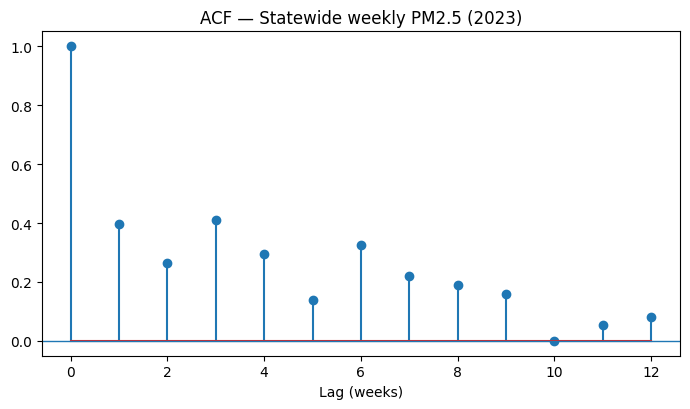

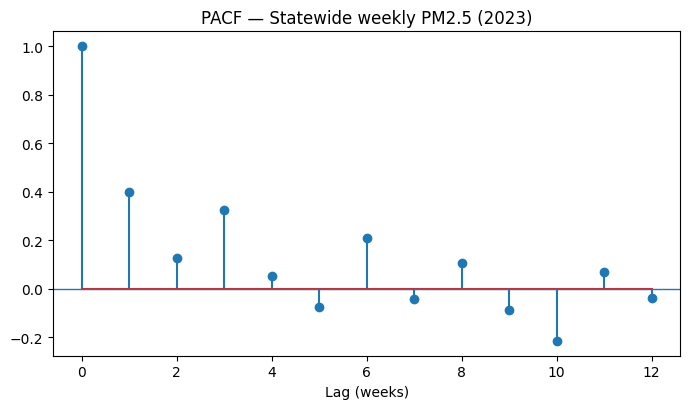

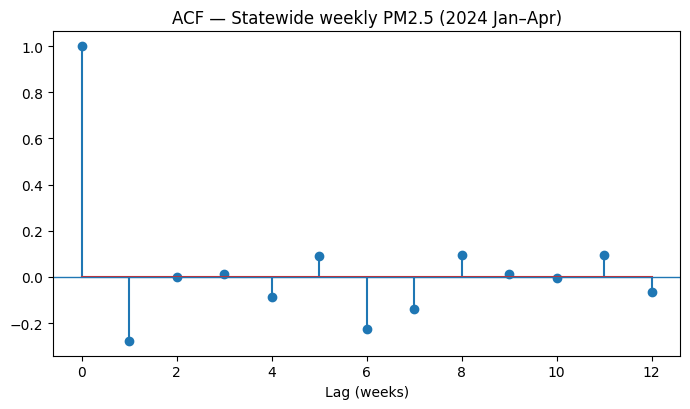

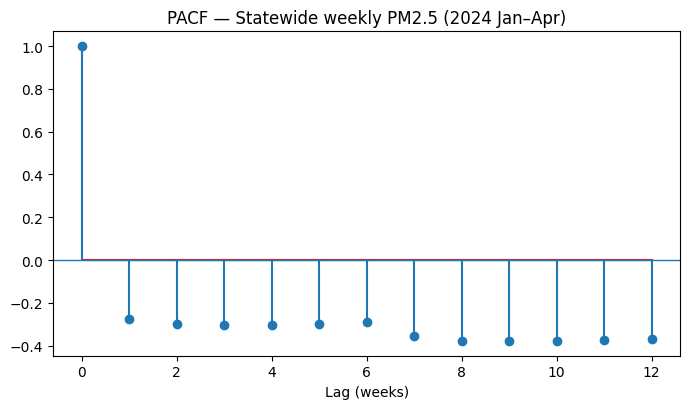

,County,ACF_lag1,ACF_lag2,ACF_lag3,ACF_lag4,ACF_lag5,ACF_lag6,PACF_lag1,PACF_lag2,PACF_lag3,PACF_lag4,PACF_lag5,PACF_lag6
0,Alameda,0.384057,0.288938,0.313478,0.151056,0.019236,0.183409,0.384057,0.165910,0.189620,-0.053443,-0.124708,0.179896
1,Butte,0.448163,0.309617,0.382391,0.260289,0.142531,0.313126,0.448163,0.136104,0.256929,-0.001194,-0.057866,0.233168
2,Calaveras,0.518989,0.361042,0.458792,0.329921,0.257566,0.396484,0.518989,0.125494,0.319547,-0.028954,0.034967,0.221838
3,Colusa,0.738038,0.655523,0.691696,0.609584,0.510077,0.554686,0.738038,0.243406,0.340893,-0.014876,-0.098253,0.169833
4,Contra Costa,0.405940,0.280574,0.327667,0.167169,0.015317,0.168197,0.405940,0.138631,0.211539,-0.053431,-0.134452,0.164243
5,Del Norte,0.733231,0.482696,0.375789,0.194474,-0.005639,-0.104858,0.733231,-0.118805,0.146813,-0.252283,-0.122332,-0.027624
6,El Dorado,0.279383,0.009239,0.184747,0.052281,0.009001,0.190199,0.279383,-0.074642,0.221231,-0.076545,0.044679,0.158867
7,Fresno,0.649984,0.566072,0.580717,0.475593,0.354843,0.459505,0.649984,0.248636,0.263285,-0.018026,-0.121326,0.258785
8,Glenn,0.526437,0.401365,0.467851,0.338140,0.231169,0.388473,0.526437,0.171857,0.288515,-0.020224,-0.049368,0.255430
9,Humboldt,0.600624,0.351752,0.307359,0.184481,-0.034606,-0.091909,0.600624,-0.014075,0.158918,-0.096092,-0.213366,-0.001846


In [3]:
# ACF & PACF for county-level PM2.5 (2023 + 2024 Jan–Apr check)

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt

# Try statsmodels; fall back to simple implementations if unavailable
try:
    from statsmodels.tsa.stattools import acf as sm_acf, pacf as sm_pacf
    HAVE_SM = True
except Exception:
    HAVE_SM = False

DATA_2023_AGG = "pm25_2023_by_county_week_cov.csv"
DATA_2024_AGG = "pm25_2024_by_county_week_cov.csv"
RAW_2023 = "full_2023_weekly_averages.csv"
RAW_2024 = "full_2024_weekly_averages.csv"

def load_county_week(path_agg, path_raw):
    """Return DF with ['County','ds','PM2.5_county_mean']."""
    if os.path.exists(path_agg):
        df = pd.read_csv(path_agg)
        df["ds"] = pd.to_datetime(df["ds"])
        return df[["County","ds","PM2.5_county_mean"]].copy()
    df_raw = pd.read_csv(path_raw)
    df_raw["Date"] = pd.to_datetime(df_raw["Date"])
    dfa = (df_raw.rename(columns={"Date":"ds"})
                  .groupby(["County","ds"], as_index=False)["PM2.5"]
                  .mean()
                  .rename(columns={"PM2.5":"PM2.5_county_mean"}))
    return dfa

d23 = load_county_week(DATA_2023_AGG, RAW_2023)
d24 = load_county_week(DATA_2024_AGG, RAW_2024)

# Statewide equal-weight weekly mean
s23 = (d23.groupby("ds", as_index=False)["PM2.5_county_mean"]
          .mean()
          .sort_values("ds"))
s24 = (d24.groupby("ds", as_index=False)["PM2.5_county_mean"]
          .mean()
          .sort_values("ds"))
s24_ja = s24[s24["ds"].dt.month.isin([1,2,3,4])].copy()

# --- PATCH: robust ACF/PACF helper (handles statsmodels method names) ---

import numpy as np

def acf_pacf_series(x, nlags=12):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    nl = nlags if len(x) >= nlags + 2 else max(1, min(6, len(x) - 2))

    try:
        from statsmodels.tsa.stattools import acf as sm_acf, pacf as sm_pacf
        acf_vals = sm_acf(x, nlags=nl, fft=True)

        # try a few method names that exist across versions
        for meth in ("ywmle", "yw", "burg"):
            try:
                pacf_vals = sm_pacf(x, nlags=nl, method=meth)
                break
            except Exception:
                pacf_vals = None
        if pacf_vals is None:
            # last resort: OLS
            pacf_vals = sm_pacf(x, nlags=nl, method="ols")

    except Exception:
        # Fallback (no statsmodels): simple ACF + Durbin–Levinson PACF
        x0 = x - x.mean()
        denom = np.dot(x0, x0)
        acf_vals = [1.0]
        for k in range(1, nl+1):
            num = np.dot(x0[:-k], x0[k:]) if k < len(x0) else 0.0
            acf_vals.append(num/denom if denom>0 else 0.0)
        acf_vals = np.array(acf_vals)

        pacf_vals = np.zeros(nl+1); pacf_vals[0] = 1.0
        phi = np.zeros((nl+1, nl+1)); var = np.zeros(nl+1)
        phi[1,1] = acf_vals[1] if len(acf_vals)>1 else 0.0
        var[0] = 1.0; var[1] = (1 - phi[1,1]**2)
        for k in range(2, nl+1):
            num = acf_vals[k] - np.sum(phi[1:k, k-1] * acf_vals[1:k][::-1])
            den = var[k-1] if var[k-1] != 0 else 1.0
            phi[k,k] = num/den
            for j in range(1, k):
                phi[j,k] = phi[j,k-1] - phi[k,k]*phi[k-j,k-1]
            var[k] = var[k-1]*(1 - phi[k,k]**2)
        pacf_vals[1:] = phi[1,1:]

    lags = np.arange(0, len(acf_vals))
    return lags, np.asarray(acf_vals), np.asarray(pacf_vals)


def plot_stem(lags, vals, title, fname, n_obs=None):
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.stem(lags, vals)  # no use_line_collection kwarg in newer Matplotlib
    ax.axhline(0, linewidth=1)

    # Optional: add ±1.96/sqrt(n) confidence bands if you pass n_obs
    if n_obs is not None and n_obs > 0:
        band = 1.96 / np.sqrt(n_obs)
        ax.axhline(band, linestyle="--", linewidth=1)
        ax.axhline(-band, linestyle="--", linewidth=1)

    ax.set_xlabel("Lag (weeks)")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(fname, dpi=200)
    plt.show()


# 2023
lags23, acf23, pacf23 = acf_pacf_series(s23["PM2.5_county_mean"].values, nlags=12)
plot_stem(lags23, acf23, "ACF — Statewide weekly PM2.5 (2023)", "acf_statewide_2023.png")
plot_stem(lags23, pacf23, "PACF — Statewide weekly PM2.5 (2023)", "pacf_statewide_2023.png")

# 2024 Jan–Apr
lags24, acf24, pacf24 = acf_pacf_series(s24_ja["PM2.5_county_mean"].values, nlags=12)
plot_stem(lags24, acf24, "ACF — Statewide weekly PM2.5 (2024 Jan–Apr)", "acf_statewide_2024_JA.png")
plot_stem(lags24, pacf24, "PACF — Statewide weekly PM2.5 (2024 Jan–Apr)", "pacf_statewide_2024_JA.png")

# County-by-county summary (2023), lags 1..6
rows = []
for county, g in d23.groupby("County", sort=False):
    g = g.sort_values("ds")
    _, a, p = acf_pacf_series(g["PM2.5_county_mean"].values, nlags=6)
    a = a[1:7] if len(a) >= 7 else a[1:]
    p = p[1:7] if len(p) >= 7 else p[1:]
    row = {"County": county}
    for i, val in enumerate(a, start=1): row[f"ACF_lag{i}"] = val
    for i, val in enumerate(p, start=1): row[f"PACF_lag{i}"] = val
    rows.append(row)

summary_23 = pd.DataFrame(rows)
summary_23.to_csv("summary_acf_pacf_2023_county.csv", index=False)
summary_23.head(10)


# even though imputed county level was used, the pacf for 2023 confirms lag=3 isn't bad

# imputation smooths noise, which can slightly inflate short-lag correlations

# Seasonality (about 52 weeks) shows up in ACF; periodic kernel handles that so i don’t need very long lag stacks

# tested lags {2,3,4} and found minimal gains beyond 3 with higher compute cost